In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

with open('../docs/evaluation_results.json') as f:
    data = json.load(f)

results = pd.DataFrame(data['results'])
print(f"Overall Accuracy: {data['accuracy']:.1f}%")
print(f"Total cases: {data['total']}")
print(results[['engine_id', 'rul_actual', 'expected_status', 'actual_status', 'correct', 'elapsed_seconds']])

Overall Accuracy: 100.0%
Total cases: 9
   engine_id  rul_actual expected_status actual_status  correct  \
0          1          19        CRITICAL      CRITICAL     True   
1          1          49         WARNING       WARNING     True   
2          1         181         HEALTHY       HEALTHY     True   
3          5          19        CRITICAL      CRITICAL     True   
4          5          49         WARNING       WARNING     True   
5          5         258         HEALTHY       HEALTHY     True   
6         10          19        CRITICAL      CRITICAL     True   
7         10          49         WARNING       WARNING     True   
8         10         211         HEALTHY       HEALTHY     True   

   elapsed_seconds  
0           146.82  
1            88.80  
2            99.66  
3           104.37  
4           108.24  
5            89.01  
6            89.90  
7            78.84  
8            84.69  


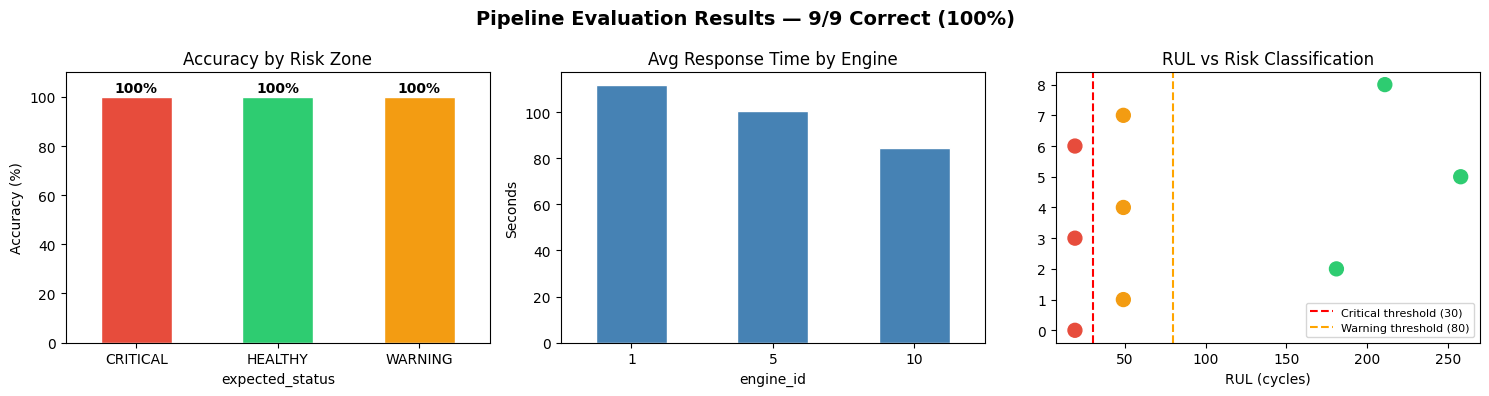

Plot saved!


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Accuracy by risk zone
status_acc = results.groupby('expected_status')['correct'].mean() * 100
colors = {'CRITICAL': '#e74c3c', 'WARNING': '#f39c12', 'HEALTHY': '#2ecc71'}
status_acc.plot(kind='bar', ax=axes[0], 
                color=[colors[s] for s in status_acc.index],
                edgecolor='white')
axes[0].set_title('Accuracy by Risk Zone')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 110)
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(status_acc):
    axes[0].text(i, v + 2, f'{v:.0f}%', ha='center', fontweight='bold')

# Plot 2 — Response time by engine
results.groupby('engine_id')['elapsed_seconds'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Avg Response Time by Engine')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=0)

# Plot 3 — RUL vs actual status
status_colors = results['actual_status'].map(colors)
axes[2].scatter(results['rul_actual'], range(len(results)), 
                c=status_colors, s=100)
axes[2].axvline(x=30, color='red', linestyle='--', label='Critical threshold (30)')
axes[2].axvline(x=80, color='orange', linestyle='--', label='Warning threshold (80)')
axes[2].set_title('RUL vs Risk Classification')
axes[2].set_xlabel('RUL (cycles)')
axes[2].legend(fontsize=8)

plt.suptitle('Pipeline Evaluation Results — 9/9 Correct (100%)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/evaluation_results.png', dpi=150)
plt.show()
print("Plot saved!")

In [3]:
summary = results[['engine_id', 'rul_actual', 'expected_status', 
                    'actual_status', 'correct', 'elapsed_seconds']].copy()
summary.columns = ['Engine', 'RUL', 'Expected', 'Actual', 'Correct', 'Time (s)']
summary['Correct'] = summary['Correct'].map({True: '✅', False: '❌'})
print(summary.to_string(index=False))

 Engine  RUL Expected   Actual Correct  Time (s)
      1   19 CRITICAL CRITICAL       ✅    146.82
      1   49  WARNING  WARNING       ✅     88.80
      1  181  HEALTHY  HEALTHY       ✅     99.66
      5   19 CRITICAL CRITICAL       ✅    104.37
      5   49  WARNING  WARNING       ✅    108.24
      5  258  HEALTHY  HEALTHY       ✅     89.01
     10   19 CRITICAL CRITICAL       ✅     89.90
     10   49  WARNING  WARNING       ✅     78.84
     10  211  HEALTHY  HEALTHY       ✅     84.69
